
# 04_visual_semantic_intelligence.ipynb

## Production-Grade Visual Semantic Intelligence Pipeline

This redesigned notebook fixes:
- stale Kaggle runtime paths
- many-to-many merge explosions
- ASIN/image alignment issues
- OCR scalability limitations
- artifact restoration instability

The pipeline now follows a proper:
# IMAGE-GRANULAR MULTIMODAL ARCHITECTURE

Core capabilities:
- runtime artifact restoration
- scalable OCR
- color intelligence
- fashion attribute extraction
- visual category inference
- semantic consistency analysis
- duplicate intelligence
- enterprise exports


In [1]:

!pip install -q easyocr
!pip install -q colorthief
!pip install -q rapidfuzz
!pip install -q pyarrow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 80.0 MB/s eta 0:00:00


In [2]:

import os
import gc
import cv2
import json
import glob
import torch
import warnings

import easyocr
import numpy as np
import pandas as pd

from pathlib import Path
from collections import Counter, defaultdict

from tqdm.auto import tqdm

from PIL import Image
from colorthief import ColorThief

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)


In [3]:

BASE_DIR = "/kaggle/working"

VISUAL_DIR = (
    f"{BASE_DIR}/visual_intelligence"
)

os.makedirs(
    VISUAL_DIR,
    exist_ok=True
)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE:", DEVICE)


DEVICE: cuda



# Stage 1 — Load Validated Metadata


In [4]:

validated_df = pd.read_parquet(

    "/kaggle/input/notebooks/hanafudaearring/embedding-validation/artifacts_2/v2/validated_embeddings_df.parquet"
)

print(
    "VALIDATED DF SHAPE:",
    validated_df.shape
)


validated_df.head()


VALIDATED DF SHAPE: (4343, 32)


,image_path,width,height,aspect_ratio,megapixels,is_low_resolution,is_extreme_aspect_ratio,blur_score,is_blurry,brightness_score,is_dark_image,contrast_score,quality_score,is_low_quality,phash,duplicate_count,is_duplicate,tensor_path,caption,caption_length,is_empty_caption,is_repetitive_caption,image_caption_similarity,is_low_alignment,bad_embedding_norm,embedding_alignment_score,low_alignment_flag,embedding_outlier,semantic_cluster,normalized_alignment,embedding_health_score,low_embedding_health
0,/kaggle/working/artifacts/v1//downloaded_image...,400,500,0.8,0.202506,False,False,0.005658,False,0.741763,False,0.580375,0.326877,True,ea48d58e8aadb991,1,False,/kaggle/working/artifacts/v1//normalized_tenso...,men ' s polo shirt,5,False,False,0.681957,False,False,0.681957,False,False,20,0.746651,0.671388,False
1,/kaggle/working/artifacts/v1//downloaded_image...,500,500,1.0,0.253234,False,False,0.020590,False,0.764080,False,0.694872,0.373938,False,ee9c952592626b8d,1,False,/kaggle/working/artifacts/v1//normalized_tenso...,a man wearing a black polo shirt with a smile ...,12,False,False,0.486107,False,False,0.486107,False,False,3,0.488888,0.556625,False
2,/kaggle/working/artifacts/v1//downloaded_image...,500,500,1.0,0.253234,False,False,0.013650,False,0.724196,False,0.669775,0.358860,False,faecc059a53781ca,1,False,/kaggle/working/artifacts/v1//normalized_tenso...,a man wearing a grey polo shirt and white pants,10,False,False,0.410553,False,False,0.410553,False,False,21,0.389449,0.502382,False
3,/kaggle/working/artifacts/v1//downloaded_image...,500,500,1.0,0.253234,False,False,0.009926,False,0.651542,False,0.641367,0.337530,True,afe6c458991d8749,1,False,/kaggle/working/artifacts/v1//normalized_tenso...,a man walking with a golf bag,7,False,False,0.590835,False,False,0.590835,False,False,16,0.626723,0.614620,False
4,/kaggle/working/artifacts/v1//downloaded_image...,500,500,1.0,0.253234,False,False,0.006821,False,0.863412,False,0.557901,0.362279,False,a6cea6cf3938b083,1,False,/kaggle/working/artifacts/v1//normalized_tenso...,a man standing on the beach with his hands in ...,12,False,False,0.604645,False,False,0.604645,False,False,23,0.644899,0.631133,False


In [5]:

validated_df.columns.tolist()


['image_path',
 'width',
 'height',
 'aspect_ratio',
 'megapixels',
 'is_low_resolution',
 'is_extreme_aspect_ratio',
 'blur_score',
 'is_blurry',
 'brightness_score',
 'is_dark_image',
 'contrast_score',
 'quality_score',
 'is_low_quality',
 'phash',
 'duplicate_count',
 'is_duplicate',
 'tensor_path',
 'caption',
 'caption_length',
 'is_empty_caption',
 'is_repetitive_caption',
 'image_caption_similarity',
 'is_low_alignment',
 'bad_embedding_norm',
 'embedding_alignment_score',
 'low_alignment_flag',
 'embedding_outlier',
 'semantic_cluster',
 'normalized_alignment',
 'embedding_health_score',
 'low_embedding_health']


# Stage 2 — Extract Stable ASIN Keys


In [6]:

validated_df["asin"] = (

    validated_df[
        "image_path"
    ]

    .astype(str)

    .apply(
        lambda x: Path(x).stem
    )

    .str.split("_")

    .str[0]

    .str.upper()
)

validated_df[[
    "image_path",
    "asin"
]].head()


,image_path,asin
0,/kaggle/working/artifacts/v1//downloaded_image...,B0B59BJG6Y
1,/kaggle/working/artifacts/v1//downloaded_image...,B0B59BJG6Y
2,/kaggle/working/artifacts/v1//downloaded_image...,B0B59BJG6Y
3,/kaggle/working/artifacts/v1//downloaded_image...,B0B59BJG6Y
4,/kaggle/working/artifacts/v1//downloaded_image...,B0B59BJG6Y



# Stage 3 — Discover Runtime Images


In [7]:

all_images = sorted(

    glob.glob(

        "/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/*"
    )
)

print(
    "TOTAL RUNTIME IMAGES:",
    len(all_images)
)


TOTAL RUNTIME IMAGES: 4343


In [8]:

all_images[:10]


['/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4231.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4232.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4233.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4234.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4235.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4236.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B0006U6C0Q_842.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B0006U6C0Q_843.jpg',
 '/kaggle/input/no


# Stage 4 — Build ASIN → Runtime Image Mapping

This fixes:
- stale image paths
- Kaggle session resets
- many-to-many merge explosions


In [9]:

asin_to_images = defaultdict(list)

for path in all_images:

    asin = (

        Path(path)
        .stem
        .split("_")[0]
        .upper()
    )

    asin_to_images[asin].append(path)

print(
    "TOTAL UNIQUE ASINS:",
    len(asin_to_images)
)


TOTAL UNIQUE ASINS: 728


In [10]:

sample_asin = list(
    asin_to_images.keys()
)[0]

print(sample_asin)

asin_to_images[sample_asin][:5]


B00021NY28


['/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4231.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4232.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4233.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4234.jpg',
 '/kaggle/input/notebooks/hanafudaearring/media-resolution-captioning/artifacts/v1/downloaded_images/B00021NY28_4235.jpg']


# Stage 5 — Runtime Path Restoration

CRITICAL FIX:
We restore runtime image paths WITHOUT changing row count.


In [11]:

asin_image_counters = defaultdict(int)

new_paths = []

for asin in tqdm(
    validated_df["asin"]
):

    images = asin_to_images.get(
        asin,
        []
    )

    idx = asin_image_counters[asin]

    if idx < len(images):

        new_paths.append(
            images[idx]
        )

        asin_image_counters[asin] += 1

    else:

        new_paths.append(None)


  0%|          | 0/4343 [00:00<?, ?it/s]

In [12]:

validated_df[
    "image_path_runtime"
] = new_paths


In [13]:

validated_df[[
    "asin",
    "image_path_runtime"
]].head(20)


,asin,image_path_runtime
0,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...
1,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...
2,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...
3,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...
4,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...
5,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...
6,B0DLGB4RYH,/kaggle/input/notebooks/hanafudaearring/media-...
7,B0DLGB4RYH,/kaggle/input/notebooks/hanafudaearring/media-...
8,B0DLGB4RYH,/kaggle/input/notebooks/hanafudaearring/media-...
9,B0DLGB4RYH,/kaggle/input/notebooks/hanafudaearring/media-...


In [14]:

validated_df = validated_df[

    validated_df[
        "image_path_runtime"
    ].notnull()
].reset_index(drop=True)

print(
    "ROWS AFTER RUNTIME RESTORATION:",
    len(validated_df)
)


ROWS AFTER RUNTIME RESTORATION: 4343


In [15]:

validated_df["image_exists"] = [

    os.path.exists(path)

    for path in tqdm(
        validated_df[
            "image_path_runtime"
        ]
    )
]

print(
    "VALID IMAGES:",
    validated_df[
        "image_exists"
    ].sum()
)


  0%|          | 0/4343 [00:00<?, ?it/s]

VALID IMAGES: 4343


In [16]:

validated_df = validated_df[

    validated_df[
        "image_exists"
    ]
].reset_index(drop=True)

print(
    "FINAL DATASET SIZE:",
    len(validated_df)
)


FINAL DATASET SIZE: 4343


In [17]:

validated_df.isnull().mean().sort_values(
    ascending=False
).head(20)


image_path                 0.0
width                      0.0
height                     0.0
aspect_ratio               0.0
megapixels                 0.0
is_low_resolution          0.0
is_extreme_aspect_ratio    0.0
blur_score                 0.0
is_blurry                  0.0
brightness_score           0.0
is_dark_image              0.0
contrast_score             0.0
quality_score              0.0
is_low_quality             0.0
phash                      0.0
duplicate_count            0.0
is_duplicate               0.0
tensor_path                0.0
caption                    0.0
caption_length             0.0
dtype: float64


# Stage 6 — OCR Infrastructure


In [18]:

reader = easyocr.Reader(

    ['en'],

    gpu=torch.cuda.is_available()
)


In [19]:

def extract_ocr(image_path):

    try:

        results = reader.readtext(

            image_path,

            detail=1,

            paragraph=True
        )

        texts = []
        confidences = []

        for r in results:

            texts.append(r[1])
            confidences.append(r[2])

        return {

            "ocr_text":
                " ".join(texts),

            "ocr_confidence":
                float(
                    np.mean(confidences)
                ) if confidences else 0
        }

    except Exception as e:

        return {

            "ocr_text": "",

            "ocr_confidence": 0,

            "ocr_error": str(e)
        }


In [20]:

sample_df = validated_df.sample(
    20,
    random_state=42
).reset_index(drop=True)

sample_df.shape


(20, 35)

In [21]:

sample_results = []

for path in tqdm(
    sample_df[
        "image_path_runtime"
    ]
):

    sample_results.append(
        extract_ocr(path)
    )

sample_ocr_df = pd.DataFrame(
    sample_results
)

sample_ocr_df.head()


  0%|          | 0/20 [00:00<?, ?it/s]

,ocr_text,ocr_confidence,ocr_error
0,,0,NaN
1,,0,NaN
2,,0,NaN
3,,0,NaN
4,,0,list index out of range


In [22]:

print(
    "OCR DETECTED:",
    (
        sample_ocr_df[
            "ocr_text"
        ].str.len() > 0
    ).sum()
)

print(
    "OCR FAILURES:",
    (
        sample_ocr_df[
            "ocr_confidence"
        ] == 0
    ).sum()
)


OCR DETECTED: 0
OCR FAILURES: 20



# Stage 7 — Chunked OCR Processing


In [23]:

OCR_DIR = (
    f"{VISUAL_DIR}/ocr_chunks"
)

os.makedirs(
    OCR_DIR,
    exist_ok=True
)

OCR_BATCH_SIZE = 32


In [24]:

for start_idx in range(

    0,
    len(validated_df),
    OCR_BATCH_SIZE
):

    chunk_path = (

        f"{OCR_DIR}/"
        f"ocr_chunk_{start_idx}.parquet"
    )

    if os.path.exists(chunk_path):
        continue

    batch_df = validated_df.iloc[
        start_idx:start_idx + OCR_BATCH_SIZE
    ].copy()

    batch_results = []

    for path in tqdm(
        batch_df[
            "image_path_runtime"
        ]
    ):

        batch_results.append(
            extract_ocr(path)
        )

    batch_ocr_df = pd.DataFrame(
        batch_results
    )

    export_df = pd.concat(

        [
            batch_df.reset_index(drop=True),
            batch_ocr_df
        ],

        axis=1
    )

    export_df.to_parquet(
        chunk_path,
        index=False
    )

    gc.collect()


  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

In [25]:

ocr_chunks = sorted(

    glob.glob(
        f"{OCR_DIR}/*.parquet"
    )
)

ocr_df = pd.concat(

    [pd.read_parquet(f)
     for f in ocr_chunks],

    ignore_index=True
)

ocr_df.shape


(4343, 38)


# Stage 8 — OCR Analytics


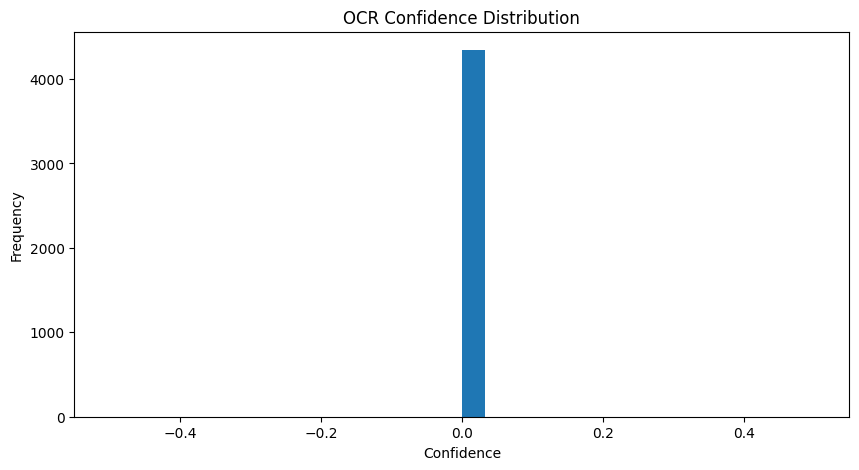

In [26]:

plt.figure(figsize=(10,5))

plt.hist(

    ocr_df[
        "ocr_confidence"
    ],

    bins=30
)

plt.title(
    "OCR Confidence Distribution"
)

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.show()



# Stage 9 — Color Intelligence


In [27]:

def extract_dominant_color(image_path):

    try:

        color_thief = ColorThief(
            image_path
        )

        return color_thief.get_color(
            quality=1
        )

    except:

        return (0,0,0)


In [28]:

ocr_df["dominant_color"] = [

    extract_dominant_color(path)

    for path in tqdm(
        ocr_df[
            "image_path_runtime"
        ]
    )
]


  0%|          | 0/4343 [00:00<?, ?it/s]

In [29]:

ocr_df["color_r"] = (
    ocr_df[
        "dominant_color"
    ].apply(lambda x: x[0])
)


ocr_df["color_g"] = (
    ocr_df[
        "dominant_color"
    ].apply(lambda x: x[1])
)

ocr_df["color_b"] = (
    ocr_df[
        "dominant_color"
    ].apply(lambda x: x[2])
)


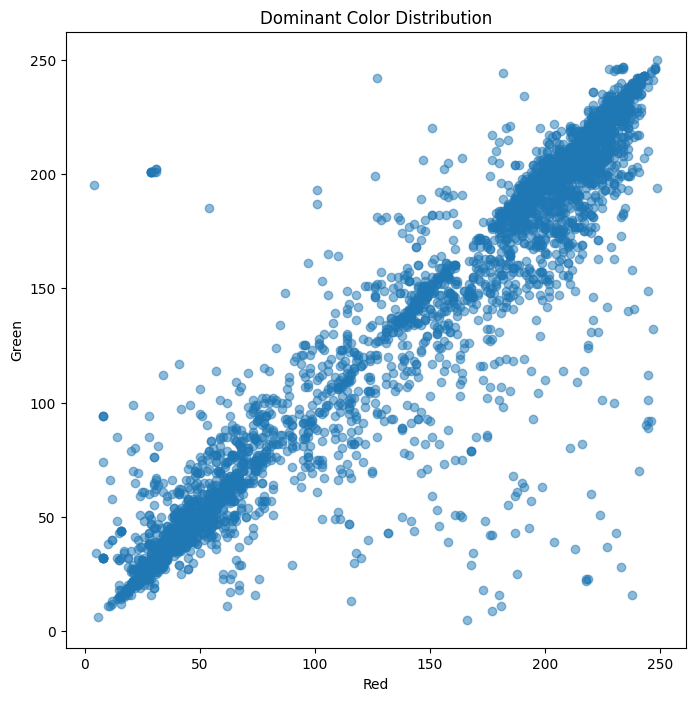

In [30]:

plt.figure(figsize=(8,8))

plt.scatter(

    ocr_df["color_r"],
    ocr_df["color_g"],

    alpha=0.5
)

plt.title(
    "Dominant Color Distribution"
)

plt.xlabel("Red")
plt.ylabel("Green")

plt.show()



# Stage 10 — Fashion Attribute Extraction


In [31]:

fashion_keywords = [

    "plaid",
    "striped",
    "floral",
    "denim",
    "formal",
    "casual",
    "hoodie",
    "jacket",
    "dress",
    "shirt",
    "jeans",
    "shoe",
    "sneaker",
    "kurta",
    "saree",
    "blazer",
    "polo"
]


In [32]:

def extract_fashion_attributes(text):

    text = str(text).lower()

    found = []

    for kw in fashion_keywords:

        if kw in text:
            found.append(kw)

    return found


In [33]:

ocr_df[
    "fashion_attributes"
] = (

    ocr_df[
        "caption"

    ].apply(
        extract_fashion_attributes
    )
)


In [34]:

attribute_counter = Counter()

for attrs in ocr_df[
    "fashion_attributes"
]:

    attribute_counter.update(attrs)

dict(
    attribute_counter.most_common(15)
)


{'shirt': 1068,
 'jeans': 435,
 'shoe': 245,
 'jacket': 219,
 'dress': 212,
 'polo': 181,
 'sneaker': 100,
 'floral': 92,
 'striped': 79,
 'plaid': 49,
 'denim': 45,
 'hoodie': 41,
 'casual': 12,
 'blazer': 4,
 'saree': 4}

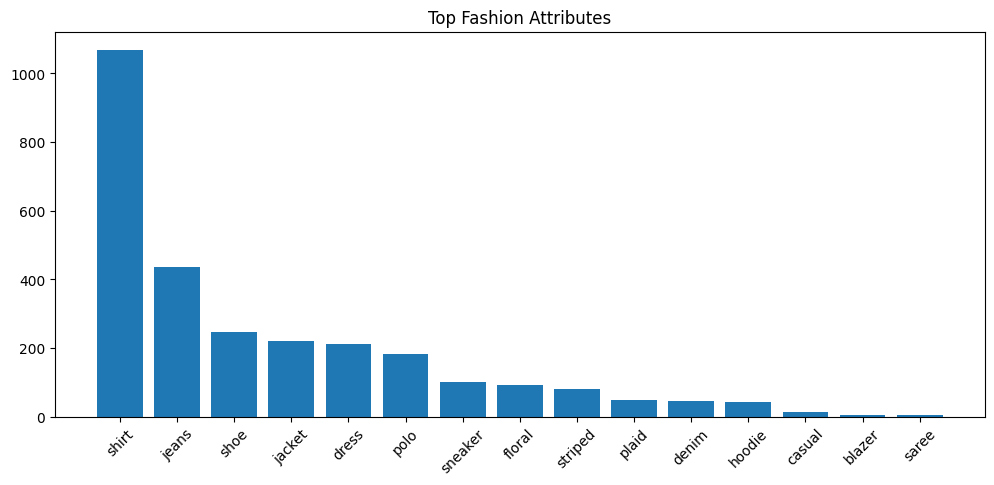

In [35]:

top_attrs = dict(
    attribute_counter.most_common(15)
)

plt.figure(figsize=(12,5))

plt.bar(
    top_attrs.keys(),
    top_attrs.values()
)

plt.xticks(rotation=45)

plt.title(
    "Top Fashion Attributes"
)

plt.show()



# Stage 11 — Visual Category Inference


In [36]:

category_keywords = {

    "footwear":
        ["shoe", "sneaker"],

    "tops":
        ["shirt", "hoodie", "jacket"],

    "bottoms":
        ["jeans"],

    "ethnic":
        ["kurta", "saree"],

    "dresses":
        ["dress"],

    "formalwear":
        ["blazer"]
}


In [37]:

def infer_category(attrs):

    attrs = set(attrs)

    for category, kws in (
        category_keywords.items()
    ):

        for kw in kws:

            if kw in attrs:
                return category

    return "unknown"


In [38]:

ocr_df[
    "visual_category"
] = (

    ocr_df[
        "fashion_attributes"
    ].apply(
        infer_category
    )
)


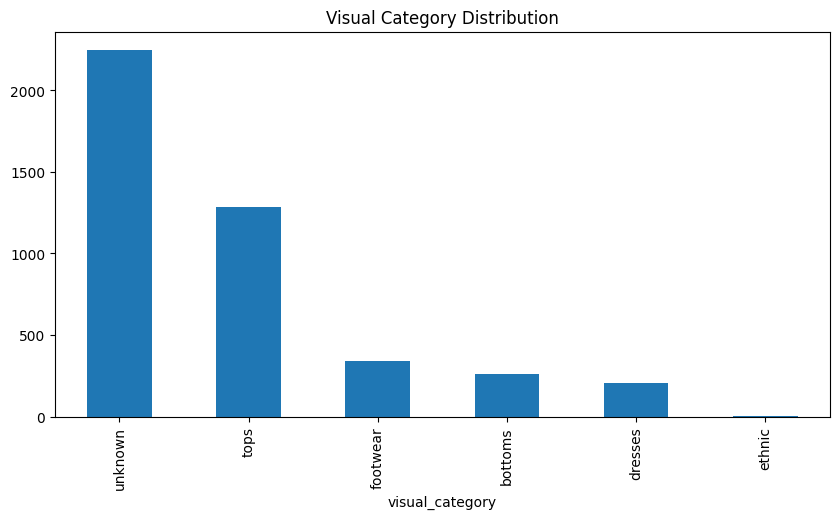

In [39]:

ocr_df[
    "visual_category"
].value_counts().plot.bar(
    figsize=(10,5)
)

plt.title(
    "Visual Category Distribution"
)

plt.show()



# Stage 12 — Semantic Consistency


In [40]:

def text_overlap(a, b):

    a = set(
        str(a).lower().split()
    )

    b = set(
        str(b).lower().split()
    )

    if len(a) == 0:
        return 0

    return len(a & b) / len(a)


In [41]:

ocr_df[
    "ocr_caption_overlap"
] = [

    text_overlap(
        ocr,
        caption
    )

    for ocr, caption in zip(

        ocr_df["ocr_text"],

        ocr_df["caption"]
    )
]


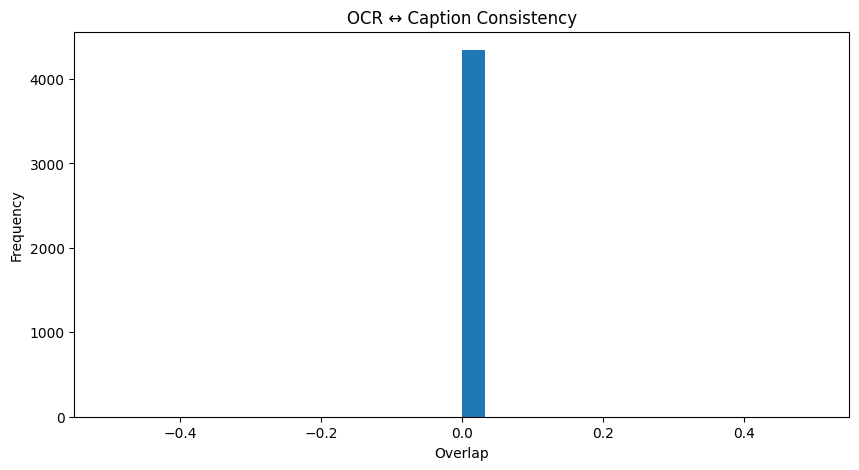

In [42]:

plt.figure(figsize=(10,5))

plt.hist(

    ocr_df[
        "ocr_caption_overlap"
    ],

    bins=30
)

plt.title(
    "OCR ↔ Caption Consistency"
)

plt.xlabel("Overlap")

plt.ylabel("Frequency")

plt.show()



# Stage 13 — Final Exports


In [43]:

final_visual_df = ocr_df[[

    "asin",

    "image_path_runtime",

    "caption",

    "ocr_text",

    "ocr_confidence",

    "dominant_color",

    "fashion_attributes",

    "visual_category",

    "ocr_caption_overlap",

    "quality_score",

    "embedding_health_score",

    "semantic_cluster",

    "is_duplicate"
]]


In [44]:

final_visual_df.to_parquet(

    f"{VISUAL_DIR}/final_visual_semantics.parquet",

    index=False
)

print(
    "EXPORTED:"
)

print(
    f"{VISUAL_DIR}/final_visual_semantics.parquet"
)


EXPORTED:
/kaggle/working/visual_intelligence/final_visual_semantics.parquet


In [45]:

health_report = {

    "total_rows":
        int(len(final_visual_df)),

    "unique_asins":
        int(
            final_visual_df[
                "asin"
            ].nunique()
        ),

    "visual_categories":
        int(
            final_visual_df[
                "visual_category"
            ].nunique()
        ),

    "duplicate_products":
        int(
            final_visual_df[
                "is_duplicate"
            ].sum()
        ),

    "ocr_detected":
        int(
            (
                final_visual_df[
                    "ocr_text"
                ].str.len() > 0
            ).sum()
        )
}

health_report


{'total_rows': 4343,
 'unique_asins': 728,
 'visual_categories': 6,
 'duplicate_products': 333,
 'ocr_detected': 0}

In [46]:

with open(

    f"{VISUAL_DIR}/visual_health_report.json",

    "w"

) as f:

    json.dump(
        health_report,
        f,
        indent=4
    )

print("=" * 60)

print(
    "VISUAL SEMANTIC INTELLIGENCE COMPLETE"
)

print("=" * 60)

print(
    "FINAL ROWS:",
    len(final_visual_df)
)

print(
    "UNIQUE ASINS:",
    final_visual_df[
        "asin"
    ].nunique()
)

print(
    "OCR DETECTED:",
    (
        final_visual_df[
            "ocr_text"
        ].str.len() > 0
    ).sum()
)

print("=" * 60)


VISUAL SEMANTIC INTELLIGENCE COMPLETE
FINAL ROWS: 4343
UNIQUE ASINS: 728
OCR DETECTED: 0



# Stage 14 — Advanced Color Intelligence Upgrade

This upgrade adds:
- dominant RGB extraction
- color naming
- product palette analytics
- color-aware retrieval signals


In [47]:

from PIL import Image
from sklearn.cluster import KMeans

COLOR_NAME_MAP = {
    "black": (0,0,0),
    "white": (255,255,255),
    "red": (255,0,0),
    "green": (0,128,0),
    "blue": (0,0,255),
    "yellow": (255,255,0),
    "brown": (165,42,42),
    "gray": (128,128,128),
    "pink": (255,192,203),
    "purple": (128,0,128),
    "orange": (255,165,0)
}

def closest_color(rgb):

    rgb = np.array(rgb)

    best_name = None
    best_dist = 1e9

    for name, value in COLOR_NAME_MAP.items():

        dist = np.linalg.norm(
            rgb - np.array(value)
        )

        if dist < best_dist:

            best_dist = dist
            best_name = name

    return best_name


In [48]:

def extract_dominant_rgb(image_path):

    try:

        img = Image.open(image_path).convert("RGB")

        img = img.resize((128,128))

        arr = np.array(img).reshape(-1,3)

        kmeans = KMeans(
            n_clusters=3,
            random_state=42,
            n_init=10
        )

        kmeans.fit(arr)

        dominant = kmeans.cluster_centers_[0]

        return tuple(
            dominant.astype(int)
        )

    except:

        return (0,0,0)


In [49]:

validated_df["dominant_rgb"] = [

    extract_dominant_rgb(path)

    for path in tqdm(
        validated_df[
            "image_path_runtime"
        ]
    )
]

validated_df["color_r"] = (
    validated_df[
        "dominant_rgb"
    ].apply(lambda x: x[0])
)

validated_df["color_g"] = (
    validated_df[
        "dominant_rgb"
    ].apply(lambda x: x[1])
)

validated_df["color_b"] = (
    validated_df[
        "dominant_rgb"
    ].apply(lambda x: x[2])
)

validated_df["dominant_color_name"] = (

    validated_df[
        "dominant_rgb"
    ].apply(
        closest_color
    )
)

validated_df[[
    "dominant_rgb",
    "dominant_color_name"
]].head()


  0%|          | 0/4343 [00:00<?, ?it/s]

,dominant_rgb,dominant_color_name
0,"(254, 254, 254)",white
1,"(247, 247, 247)",white
2,"(91, 85, 83)",gray
3,"(154, 158, 131)",gray
4,"(113, 134, 169)",gray


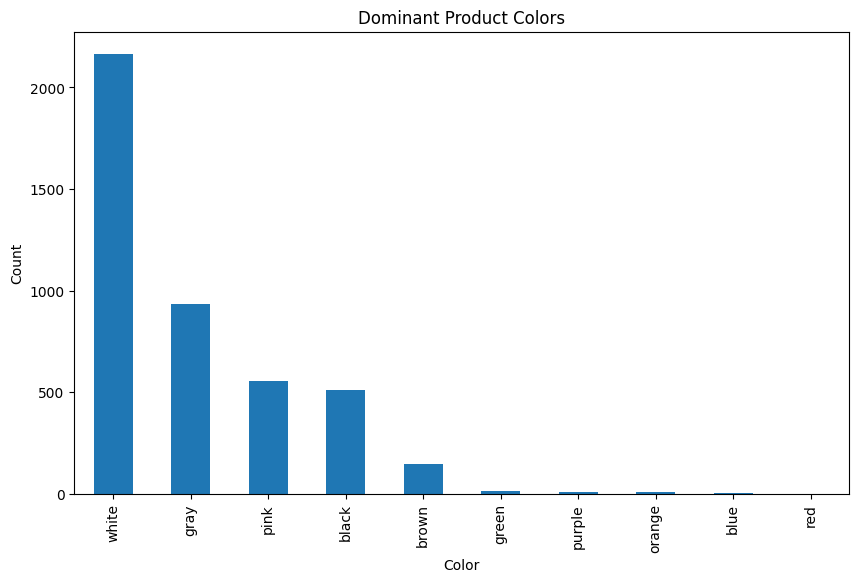

In [50]:

plt.figure(figsize=(10,6))

validated_df[
    "dominant_color_name"
].value_counts().plot.bar()

plt.title(
    "Dominant Product Colors"
)

plt.xlabel("Color")
plt.ylabel("Count")

plt.show()



# Stage 15 — Logo Retrieval Intelligence

This stage detects:
- visible brand logos
- textual branding
- logo-rich products
- logo retrieval candidates


In [51]:

LOGO_KEYWORDS = [

    "nike",
    "adidas",
    "puma",
    "reebok",
    "levi",
    "levis",
    "gucci",
    "zara",
    "hm",
    "h&m",
    "fila",
    "under armour",
    "armani",
    "lacoste"
]


In [52]:

def detect_logo_keywords(text):

    text = str(text).lower()

    found = []

    for kw in LOGO_KEYWORDS:

        if kw in text:

            found.append(kw)

    return found


In [53]:

validated_df["logo_keywords"] = (

    validated_df[
        "caption"
    ].apply(
        detect_logo_keywords
    )
)

validated_df["logo_detected"] = (

    validated_df[
        "logo_keywords"
    ].apply(
        lambda x: len(x) > 0
    )
)

validated_df[[
    "caption",
    "logo_keywords",
    "logo_detected"
]].head(20)


,caption,logo_keywords,logo_detected
0,men ' s polo shirt,[],False
1,a man wearing a black polo shirt with a smile ...,[],False
2,a man wearing a grey polo shirt and white pants,[],False
3,a man walking with a golf bag,[],False
4,a man standing on the beach with his hands in ...,[],False
5,a group of black and white beads,[],False
6,a man wearing a grey polo shirt,[],False
7,a man in a gray shirt and black pants stands o...,[],False
8,a man in a grey shirt and black pants standing...,[],False
9,a man in a grey shirt and black shorts standin...,[],False


In [54]:

logo_df = validated_df[

    validated_df[
        "logo_detected"
    ]
]

print(
    "LOGO DETECTED IMAGES:",
    len(logo_df)
)

logo_df[[
    "asin",
    "logo_keywords",
    "caption"
]].head(20)


LOGO DETECTED IMAGES: 199


,asin,logo_keywords,caption
180,B07BN24BLX,[nike],the nike golf polo shirt in light blue
188,B01GH5JOJY,[under armour],under armour performance polo shirt
189,B01GH5JOJY,[under armour],"under armour performance polo shirt, navy, large"
190,B01GH5JOJY,[under armour],"under armour men ' s performance polo shirt, n..."
192,B01GH5JOJY,[under armour],under armour performance polo shirt
193,B01GH5JOJY,[under armour],under armour polo shirt navy
271,B07GP4Q8Z5,[nike],nike golf polo shirt
272,B07GP4Q8Z5,[nike],nike golf polo shirt
420,B01GH5KOZ2,[under armour],under armour performance polo shirt
421,B01GH5KOZ2,[under armour],under armour polo shirt


In [55]:

logo_counts = Counter()

for kws in validated_df[
    "logo_keywords"
]:

    logo_counts.update(kws)

dict(
    logo_counts.most_common(15)
)


{'under armour': 63,
 'adidas': 54,
 'levi': 49,
 'nike': 32,
 'levis': 3,
 'puma': 1}

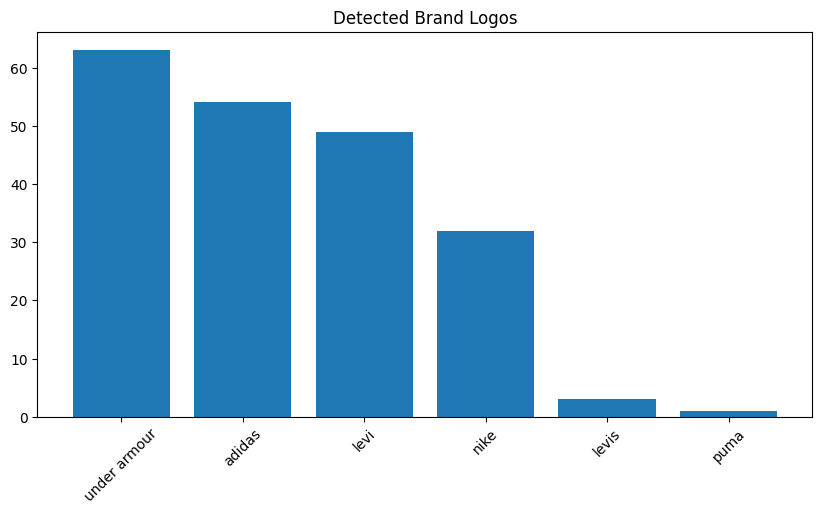

In [56]:

plt.figure(figsize=(10,5))

top_logo_counts = dict(
    logo_counts.most_common(10)
)

plt.bar(
    top_logo_counts.keys(),
    top_logo_counts.values()
)

plt.title(
    "Detected Brand Logos"
)

plt.xticks(rotation=45)

plt.show()



# Stage 16 — Upgraded Export Schema


In [57]:
desired_columns = [

    "asin",

    "image_path_runtime",

    "caption",

    "quality_score",

    "embedding_health_score",

    "semantic_cluster",

    "is_duplicate",

    "visual_category",

    "fashion_attributes",

    "dominant_rgb",

    "dominant_color_name",

    "color_r",

    "color_g",

    "color_b",

    "logo_keywords",

    "logo_detected"
]

In [58]:
available_columns = [

    c for c in desired_columns

    if c in validated_df.columns
]

In [59]:
upgraded_visual_df = validated_df[
    available_columns
].copy()

In [60]:
print(
    "AVAILABLE EXPORT COLUMNS:"
)

print(
    upgraded_visual_df.columns.tolist()
)

AVAILABLE EXPORT COLUMNS:
['asin', 'image_path_runtime', 'caption', 'quality_score', 'embedding_health_score', 'semantic_cluster', 'is_duplicate', 'dominant_rgb', 'dominant_color_name', 'color_r', 'color_g', 'color_b', 'logo_keywords', 'logo_detected']


In [61]:
upgraded_visual_df.to_parquet(

    f"{VISUAL_DIR}/final_visual_semantics_v2.parquet",

    index=False
)

print(
    "EXPORTED:"
)

print(
    f"{VISUAL_DIR}/final_visual_semantics_v2.parquet"
)

EXPORTED:
/kaggle/working/visual_intelligence/final_visual_semantics_v2.parquet


In [62]:

upgrade_report = {

    "total_rows":
        int(len(upgraded_visual_df)),

    "unique_asins":
        int(
            upgraded_visual_df[
                "asin"
            ].nunique()
        ),

    "logo_detected_images":
        int(
            upgraded_visual_df[
                "logo_detected"
            ].sum()
        ),

    "dominant_colors":
        int(
            upgraded_visual_df[
                "dominant_color_name"
            ].nunique()
        )
}

upgrade_report


{'total_rows': 4343,
 'unique_asins': 728,
 'logo_detected_images': 199,
 'dominant_colors': 10}